In [1]:
#Recency(en son ne zaman geldiği), frequency(alışveriş sıklığı) ve monetary(ne kadar harcama yapıldığı) müşteri segmentasyonu

In [2]:
import pandas as pd

In [3]:
#!pip install openpyxl
#bunu yükledikten sonra tekrar çalıştırmaya gerek yok

In [4]:
df = pd.read_excel("Online Retail.xlsx")

In [5]:
df.shape

(541909, 8)

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.dropna(inplace=True)
#dropna func gözetimsiz öğrenmede daha çok tercih edilir. 

In [9]:
df.shape

(406829, 8)

In [10]:
df = df[df['Country'] == 'United Kingdom']
df.shape

(361878, 8)

In [11]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [12]:
df.loc[:, 'TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [13]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [14]:
#RFM Hesaplama
import datetime as dt
analysis_date = df['InvoiceDate'].max() + dt.timedelta(days = 1)
analysis_date

Timestamp('2011-12-10 12:49:00')

In [15]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12747.0,2,11,4196.01
12748.0,1,224,29072.10
12749.0,4,8,3868.20
12820.0,3,4,942.34
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,3,176.60


In [16]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels = [5, 4, 3, 2, 1]) #buradaki sıralama düşük skor kötü yüksek skor iyi veri
#rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels = [5, 4, 3, 2, 1], duplicates='drop') #üst satırda hata alırsan bunu kullan 
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels = [1, 2, 3, 4, 5]) #üst satırdaki yönteme alternatif .rank(method= ) da kullanılabilir
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels = [1, 2, 3, 4, 5])
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,2,1,121
12747.0,2,11,4196.01,5,5,5,555
12748.0,1,224,29072.10,5,5,5,555
12749.0,4,8,3868.20,5,5,5,555
12820.0,3,4,942.34,5,3,4,534
...,...,...,...,...,...,...,...
18280.0,278,1,180.60,1,2,1,121
18281.0,181,1,80.82,1,2,1,121
18282.0,8,3,176.60,5,3,1,531


0    2676
2     975
3     277
1      20
4       2
Name: KMeansCluster, dtype: int64


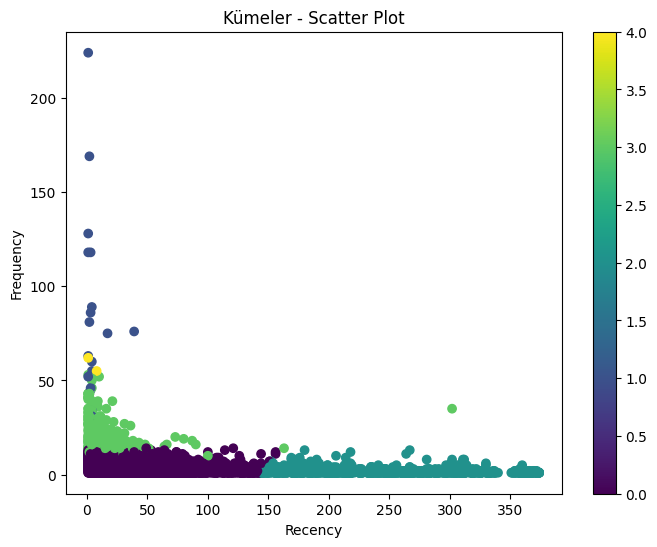

In [28]:
import matplotlib.pyplot as plt
cluster_counts = rfm['KMeansCluster'].value_counts()
print(cluster_counts)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(rfm['Recency'], rfm['Frequency'], c=rfm['KMeansCluster'], cmap='viridis')

plt.title("Kümeler - Scatter Plot")
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.colorbar(scatter)
plt.show()

In [29]:
from sklearn.cluster import KMeans

In [30]:
X = rfm[["Recency", "Frequency", "Monetary"]]
X

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12747.0,2,11,4196.01
12748.0,1,224,29072.10
12749.0,4,8,3868.20
12820.0,3,4,942.34
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,3,176.60


In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

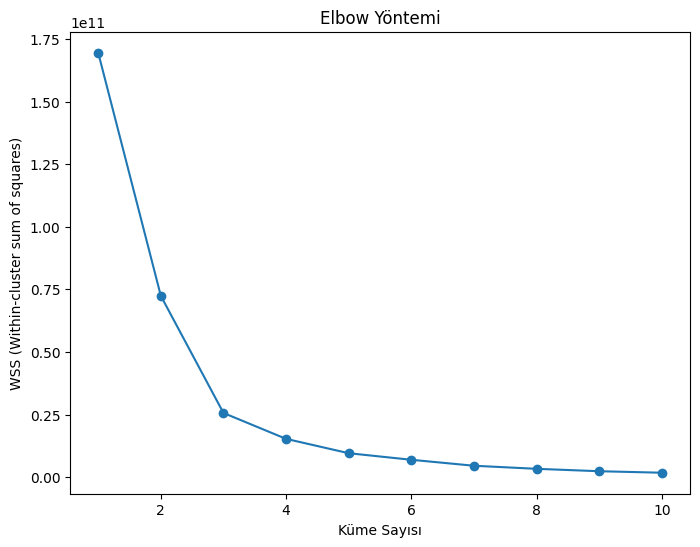

In [32]:
# Elbow Yöntemi ile en iyi küme sayısını bulma

wss = []  # Within-cluster sum of squares listesi

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(rfm)
    wss.append(kmeans.inertia_)  # inertia: WSS değeri

# WSS değerlerini grafikte çizelim
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wss, marker='o')
plt.title("Elbow Yöntemi")
plt.xlabel("Küme Sayısı")
plt.ylabel("WSS (Within-cluster sum of squares)")
plt.show()

In [33]:
kmeans = KMeans(n_clusters = 5, random_state = 42) #elbow method
rfm["KMeansCluster"] = kmeans.fit_predict(X_scaled)

In [34]:
rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,KMeansCluster
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,2,1,121,2
12747.0,2,11,4196.01,5,5,5,555,0
12748.0,1,224,29072.10,5,5,5,555,1
12749.0,4,8,3868.20,5,5,5,555,0
12820.0,3,4,942.34,5,3,4,534,0
...,...,...,...,...,...,...,...,...
18280.0,278,1,180.60,1,2,1,121,2
18281.0,181,1,80.82,1,2,1,121,2
18282.0,8,3,176.60,5,3,1,531,0


In [35]:
rfm[rfm["KMeansCluster"] == 2]

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,KMeansCluster
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,2,1,121,2
12821.0,214,1,92.72,1,1,1,111,2
12829.0,322,3,253.05,1,3,2,132,2
12831.0,262,1,215.05,1,1,1,111,2
12833.0,145,1,417.38,2,1,2,212,2
...,...,...,...,...,...,...,...,...
18256.0,355,1,-50.10,1,2,1,121,2
18260.0,173,8,2595.00,2,5,5,255,2
18269.0,358,2,138.90,1,3,1,131,2


In [37]:
import joblib
# model eğitildikten sonra
joblib.dump(kmeans, "kmeans.pkl")


['kmeans.pkl']